# Generic vs Brand Strategy
#### Is the current generic portfolio delivering sufficient financial value? 

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")

In [82]:

fact_sales = pd.read_csv('/home/andi/Documents/Pharma Sales Dataset/Fact Sales.csv')
dim_product = pd.read_csv('/home/andi/Documents/Pharma Sales Dataset/Dim Product.csv')
dim_pharmacy = pd.read_csv('/home/andi/Documents/Pharma Sales Dataset/Dim Pharmacy.csv')

In [83]:
def preview_df(df, name="DATAFRAME", head_n=5):
    print(f"{name.upper()}")
 
    # Shape of the df
    print(f"\nShape: {df.shape}")
    
    # Info about df
    print("\nInfo:")
    df.info()
    
    # Missing values
    print("\nMissing Values:")
    display(df.isna().sum())
    
    # Duplicates
    print(f"\nDuplicate Rows: {df.duplicated().sum()}")
    
    # Describe
    print("\nSummary Statistics:")
    display(df.describe().T)
    
    # Head
    print(f"\nFirst {head_n} rows:")
    display(df.head(head_n))

In [84]:
preview_df(dim_pharmacy)

DATAFRAME

Shape: (120, 10)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PharmacyID     120 non-null    object 
 1   PharmacyName   120 non-null    object 
 2   Country        120 non-null    object 
 3   Region         120 non-null    object 
 4   City           120 non-null    object 
 5   PharmacyType   120 non-null    object 
 6   OpenDate       120 non-null    object 
 7   StoreSizeBand  120 non-null    object 
 8   Latitude       120 non-null    float64
 9   Longitude      120 non-null    float64
dtypes: float64(2), object(8)
memory usage: 9.5+ KB

Missing Values:


PharmacyID       0
PharmacyName     0
Country          0
Region           0
City             0
PharmacyType     0
OpenDate         0
StoreSizeBand    0
Latitude         0
Longitude        0
dtype: int64


Duplicate Rows: 0

Summary Statistics:


,count,mean,std,min,25%,50%,75%,max
Latitude,120.0,47.936625,4.348741,37.395178,45.436314,48.53398,51.210245,54.369348
Longitude,120.0,8.189246,6.471877,-6.003924,4.350110,8.66626,13.059261,21.030542



First 5 rows:


,PharmacyID,PharmacyName,Country,Region,City,PharmacyType,OpenDate,StoreSizeBand,Latitude,Longitude
0,PH0001,Naples HealthPoint,Italy,Campania,Naples,Suburban,2025-04-03,M,40.839137,14.279288
1,PH0002,Innsbruck HealthPoint,Austria,Tyrol,Innsbruck,Urban,2011-12-21,M,47.254915,11.410136
2,PH0003,Barcelona HealthPoint,Spain,Catalonia,Barcelona,Urban,2025-04-20,M,41.386090,2.170678
3,PH0004,Katowice HealthPoint,Poland,Silesian,Katowice,Suburban,2018-07-18,L,50.260198,19.043129
4,PH0005,Poznań HealthPoint,Poland,Greater Poland,Poznań,Urban,2021-07-12,S,52.408932,16.920617


In [85]:
preview_df(dim_product)

DATAFRAME

Shape: (220, 11)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ProductID         220 non-null    object 
 1   ProductName       220 non-null    object 
 2   Category          220 non-null    object 
 3   Brand             220 non-null    object 
 4   IsGeneric         220 non-null    object 
 5   PackSize          220 non-null    object 
 6   ListPriceEUR      220 non-null    float64
 7   StandardCostEUR   220 non-null    float64
 8   LaunchDate        220 non-null    object 
 9   IsDiscontinued    220 non-null    object 
 10  DiscontinuedDate  35 non-null     object 
dtypes: float64(2), object(9)
memory usage: 19.0+ KB

Missing Values:


ProductID             0
ProductName           0
Category              0
Brand                 0
IsGeneric             0
PackSize              0
ListPriceEUR          0
StandardCostEUR       0
LaunchDate            0
IsDiscontinued        0
DiscontinuedDate    185
dtype: int64


Duplicate Rows: 0

Summary Statistics:


,count,mean,std,min,25%,50%,75%,max
ListPriceEUR,220.0,26.618727,24.237733,2.06,11.195,17.13,31.7750,111.08
StandardCostEUR,220.0,20.175409,19.272927,1.40,8.155,12.07,23.5325,82.80



First 5 rows:


,ProductID,ProductName,Category,Brand,IsGeneric,PackSize,ListPriceEUR,StandardCostEUR,LaunchDate,IsDiscontinued,DiscontinuedDate
0,PR0001,CareEquip Glucose Test Strips Compact,Medical Devices,CareEquip,No,1 unit,10.14,8.19,2018-04-09,No,NaN
1,PR0002,Medica Nasal Spray 100 mg,OTC,Medica,No,200 ml,7.03,5.52,2015-08-21,No,NaN
2,PR0003,VitaCare Vitamin C 100 mg,OTC,VitaCare,No,30 tablets,13.42,10.69,2022-11-22,No,NaN
3,PR0004,DermaSoft Shampoo Repair,Personal Care,DermaSoft,No,100 ml,15.13,8.83,2018-01-10,No,NaN
4,PR0005,CleanWave Moisturizer Sensitive,Personal Care,CleanWave,No,250 ml,14.29,10.56,2025-08-11,No,NaN


In [86]:
dim_product['LaunchDate'] = pd.to_datetime(dim_product['LaunchDate'])
dim_product['DiscontinuedDate'] = pd.to_datetime(dim_product['DiscontinuedDate'])

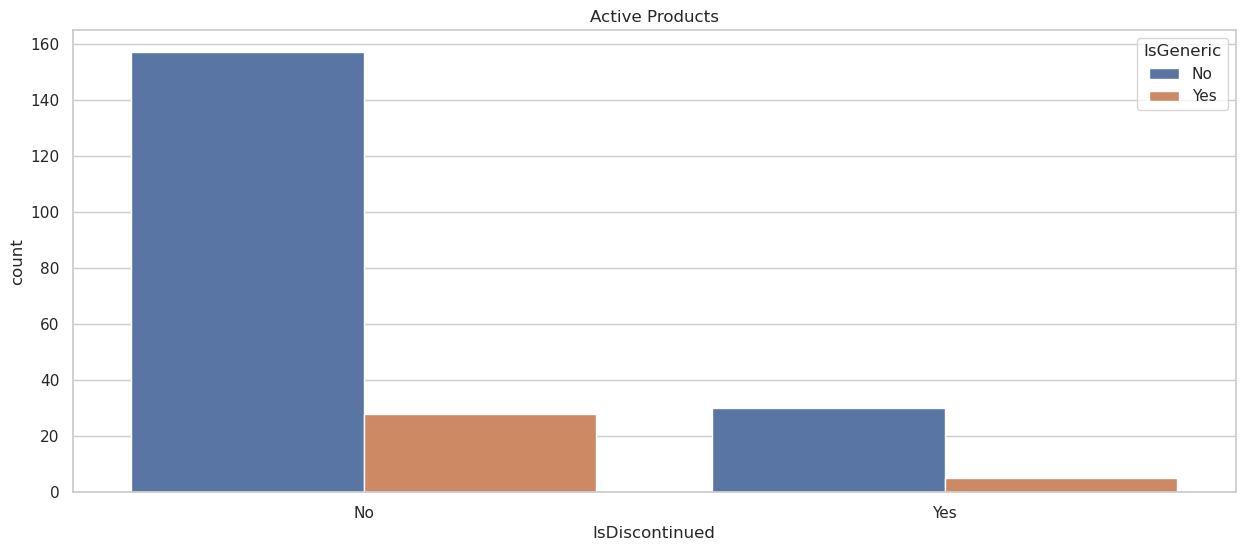

In [87]:
plt.figure(figsize=(15,6))
sns.countplot(data=dim_product, x='IsDiscontinued', hue='IsGeneric')
plt.title('Active Products')
plt.show()

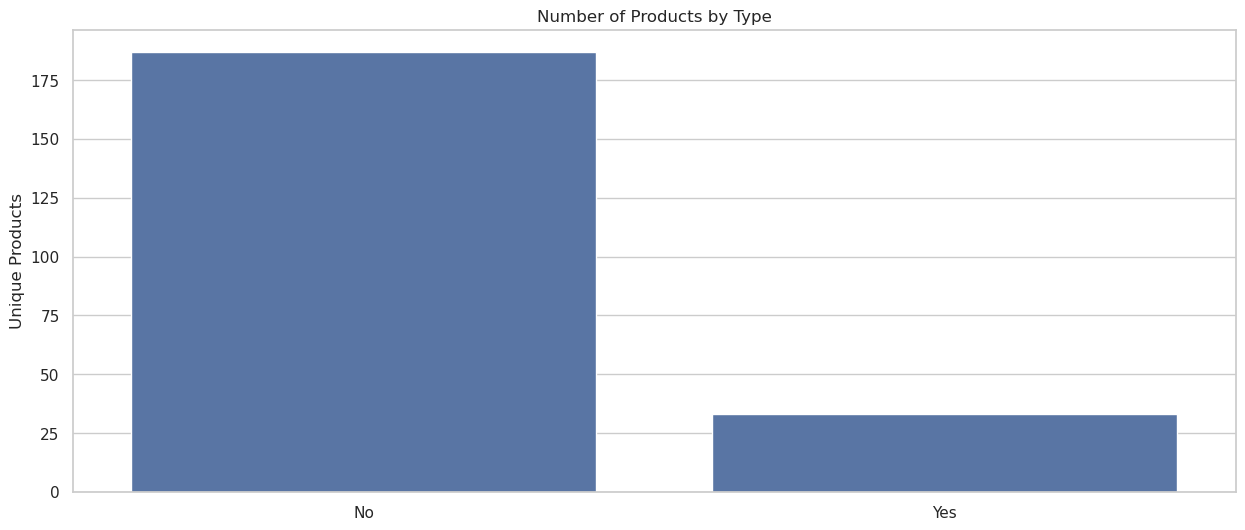

In [88]:
plt.figure(figsize=(15,6))
sns.countplot(data=dim_product[['ProductID', 'IsGeneric']].drop_duplicates(), x='IsGeneric')
plt.title('Number of Products by Type')
plt.xlabel('')
plt.ylabel('Unique Products')
plt.show()

In [89]:
pd.crosstab(dim_product['IsDiscontinued'], dim_product['IsGeneric'])

IsGeneric,No,Yes
IsDiscontinued,,
No,157,28
Yes,30,5


In [90]:
category_mix = dim_product.groupby('Category')['IsGeneric'].nunique()

eligible_categories = category_mix[category_mix == 2].index

compare_df = dim_product[dim_product['Category'].isin(eligible_categories)]

In [91]:
preview_df(fact_sales)

DATAFRAME

Shape: (62139, 9)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62139 entries, 0 to 62138
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   SalesID     62139 non-null  object 
 1   DateKey     62139 non-null  int64  
 2   PharmacyID  62139 non-null  object 
 3   ProductID   62139 non-null  object 
 4   UnitsSold   62139 non-null  int64  
 5   RevenueEUR  62139 non-null  float64
 6   CostEUR     62139 non-null  float64
 7   MarginEUR   62139 non-null  float64
 8   PromoFlag   62139 non-null  object 
dtypes: float64(3), int64(2), object(4)
memory usage: 4.3+ MB

Missing Values:


SalesID       0
DateKey       0
PharmacyID    0
ProductID     0
UnitsSold     0
RevenueEUR    0
CostEUR       0
MarginEUR     0
PromoFlag     0
dtype: int64


Duplicate Rows: 0

Summary Statistics:


,count,mean,std,min,25%,50%,75%,max
DateKey,62139.0,2.024579e+07,5014.700287,20240101.00,20240708.00,20250110.00,20250709.00,20251231.00
UnitsSold,62139.0,7.174126e+00,4.873395,1.00,3.00,6.00,10.00,25.00
RevenueEUR,62139.0,1.389462e+02,124.574712,1.61,55.25,102.75,181.35,1036.28
CostEUR,62139.0,9.998288e+01,93.611370,1.10,39.33,72.22,128.68,834.42
MarginEUR,62139.0,3.896331e+01,33.972445,0.44,15.14,28.99,51.99,295.31



First 5 rows:


,SalesID,DateKey,PharmacyID,ProductID,UnitsSold,RevenueEUR,CostEUR,MarginEUR,PromoFlag
0,S0000001,20240101,PH0002,PR0099,5,128.08,87.55,40.53,No
1,S0000002,20240101,PH0004,PR0156,4,51.89,34.32,17.57,No
2,S0000003,20240101,PH0007,PR0004,20,317.73,199.53,118.20,No
3,S0000004,20240101,PH0009,PR0075,6,90.34,67.49,22.85,No
4,S0000005,20240101,PH0010,PR0154,2,160.21,124.99,35.22,Yes


In [92]:
fact_sales['Date'] = pd.to_datetime(fact_sales['DateKey'], format='%Y%m%d')

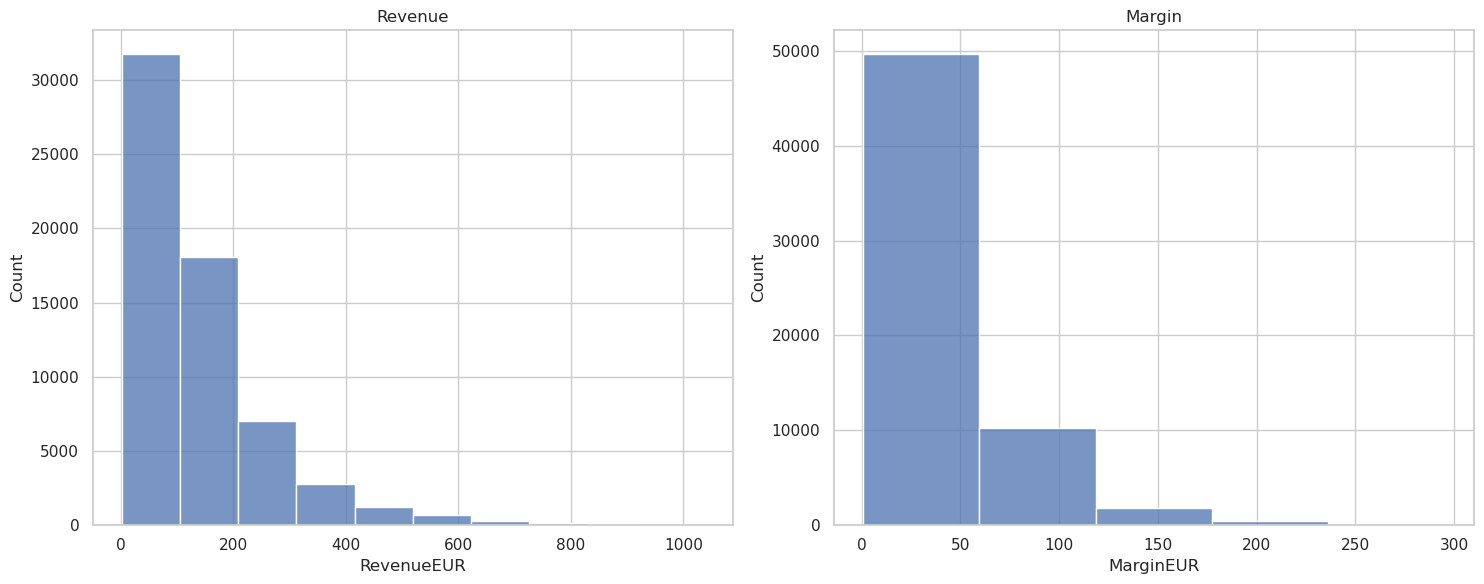

In [93]:
fig, axes = plt.subplots(1, 2, figsize=(15,6))
sns.histplot(data=fact_sales, x='RevenueEUR', ax=axes[0], bins=10)
axes[0].set_title('Revenue')

sns.histplot(data=fact_sales, x='MarginEUR', ax=axes[1], bins=5)
axes[1].set_title('Margin')

plt.tight_layout()
plt.show()

The analysis focuses on the current active product portfolio. Discontinued products were excluded because the objective is to evaluate current stocking strategy.

In [94]:
active_products = compare_df[compare_df['IsDiscontinued'] == 'No']

#### Portfolio Composition

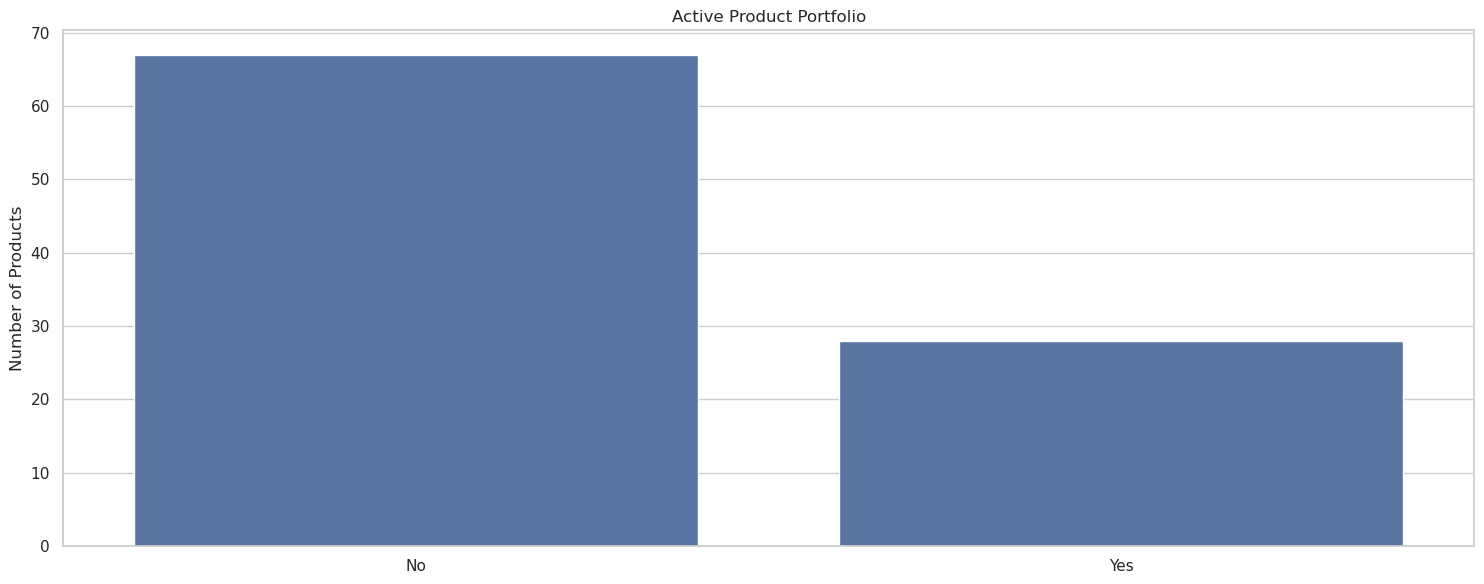

In [95]:
portfolio = active_products[['ProductID', 'IsGeneric']].drop_duplicates().groupby('IsGeneric').size().reset_index(name='Products')

plt.figure(figsize=(15,6))

sns.barplot(data=portfolio, x='IsGeneric', y='Products')

plt.title('Active Product Portfolio')
plt.xlabel('')
plt.ylabel('Number of Products')

plt.tight_layout()
plt.show()

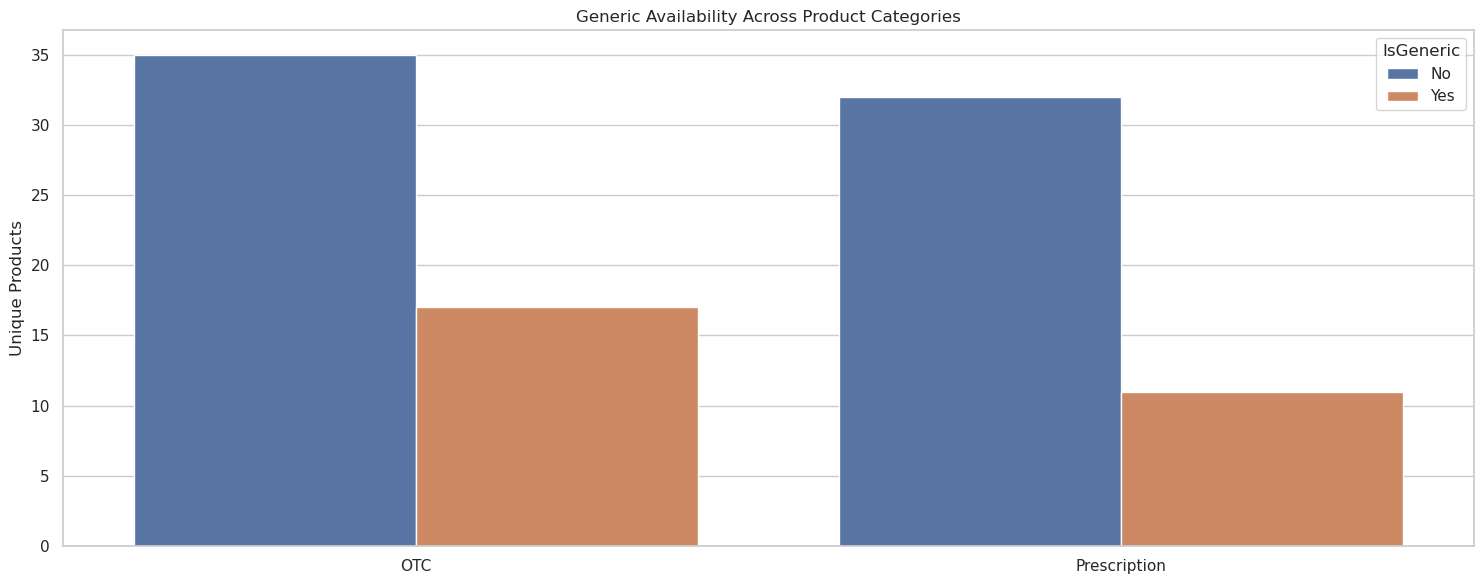

In [96]:
category_products = active_products[['ProductID','Category','IsGeneric']].drop_duplicates()

plt.figure(figsize=(15,6))

sns.countplot(data=category_products,x='Category',hue='IsGeneric')

plt.title('Generic Availability Across Product Categories')
plt.xlabel('')
plt.ylabel('Unique Products')

plt.tight_layout()
plt.show()

### Merging data to draw more insights

In [97]:
first_merge = fact_sales.merge(active_products[['IsGeneric', 'ProductName', 'Category', 'Brand']], left_on=fact_sales['ProductID'], right_on=active_products['ProductID'], how='inner')
first_merge = first_merge.drop('key_0', axis=1)

In [98]:
merged_df = first_merge.copy()

In [99]:
merged_df.tail(5)

,SalesID,DateKey,PharmacyID,ProductID,UnitsSold,RevenueEUR,CostEUR,MarginEUR,PromoFlag,Date,IsGeneric,ProductName,Category,Brand
30274,S0062129,20251231,PH0107,PR0095,7,231.29,177.36,53.93,No,2025-12-31,No,GlucoSafe ACE Inhibitor 400 mg,Prescription,GlucoSafe
30275,S0062130,20251231,PH0110,PR0177,4,42.64,31.38,11.26,No,2025-12-31,Yes,PainLess Throat Lozenges 10 mg,OTC,PainLess
30276,S0062137,20251231,PH0120,PR0183,4,43.51,30.22,13.29,No,2025-12-31,No,AllerFree Ibuprofen 20 mg,OTC,AllerFree
30277,S0062138,20251231,PH0120,PR0151,11,129.27,83.37,45.90,No,2025-12-31,No,DigestEase Allergy Tabs 40 mg,OTC,DigestEase
30278,S0062139,20251231,PH0120,PR0145,3,227.54,177.03,50.51,No,2025-12-31,No,NeuroMed Corticosteroid Cream 200 mg,Prescription,NeuroMed


## Analysing revenue and profit margin per sku

In [100]:
per_sku = merged_df.groupby(['ProductID', 'Category', 'IsGeneric'], as_index=False).agg(revenue=('RevenueEUR', 'sum'),
                                                                             margin=('MarginEUR', 'sum'),
                                                                             units=('UnitsSold', 'sum'))


sku_performance = per_sku.groupby(['Category','IsGeneric']).agg(sku_count=('ProductID', 'count'),
                                            total_revenue=('revenue', 'sum'),
                                            avg_revenue=('revenue', 'mean'),
                                            total_margin=('margin', 'sum'),
                                            avg_margin=('margin', 'mean'),
                                            total_units=('units', 'sum'),
                                            avg_units=('units', 'mean'))

sku_performance

sku_count  total_revenue   avg_revenue  total_margin  \
Category     IsGeneric                                                         
OTC          No                35     1117159.56  31918.844571     330272.05   
             Yes               17      500653.20  29450.188235     147601.69   
Prescription No                32     2054722.21  64210.069062     446554.70   
             Yes               11      594926.18  54084.198182     133952.30   

                          avg_margin  total_units    avg_units  
Category     IsGeneric                                          
OTC          No          9436.344286       110084  3145.257143  
             Yes         8682.452353        52690  3099.411765  
Prescription No         13954.834375        45230  1413.437500  
             Yes        12177.481818        15015  1365.000000

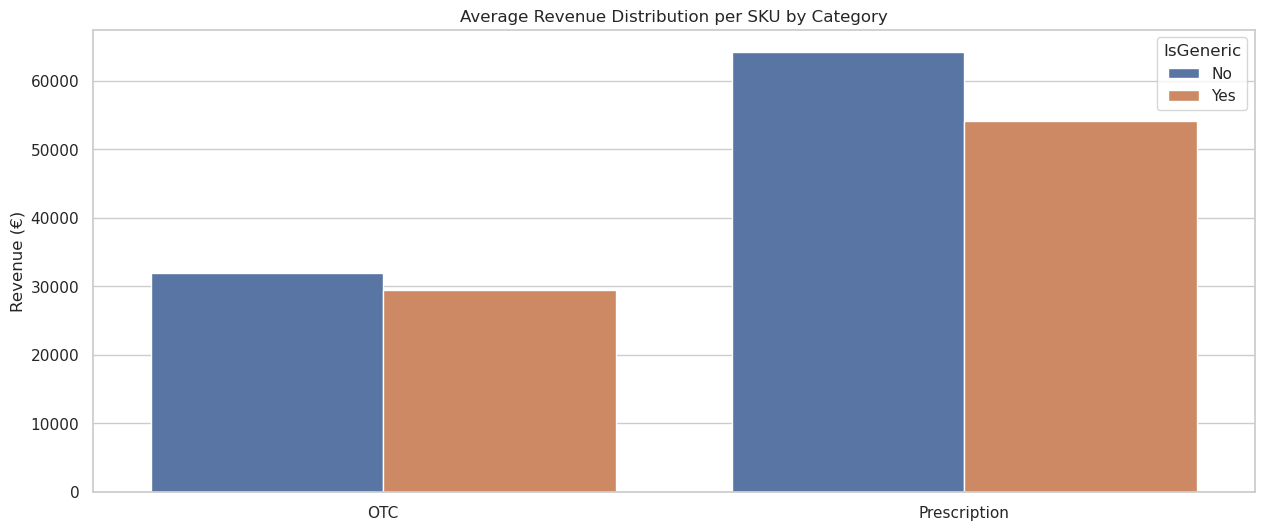

In [101]:
plt.figure(figsize=(15,6))
sns.barplot(data=sku_performance,x="Category",y="avg_revenue",hue="IsGeneric")
plt.title('Average Revenue Distribution per SKU by Category')
plt.xlabel('')
plt.ylabel('Revenue (€)')
plt.show()

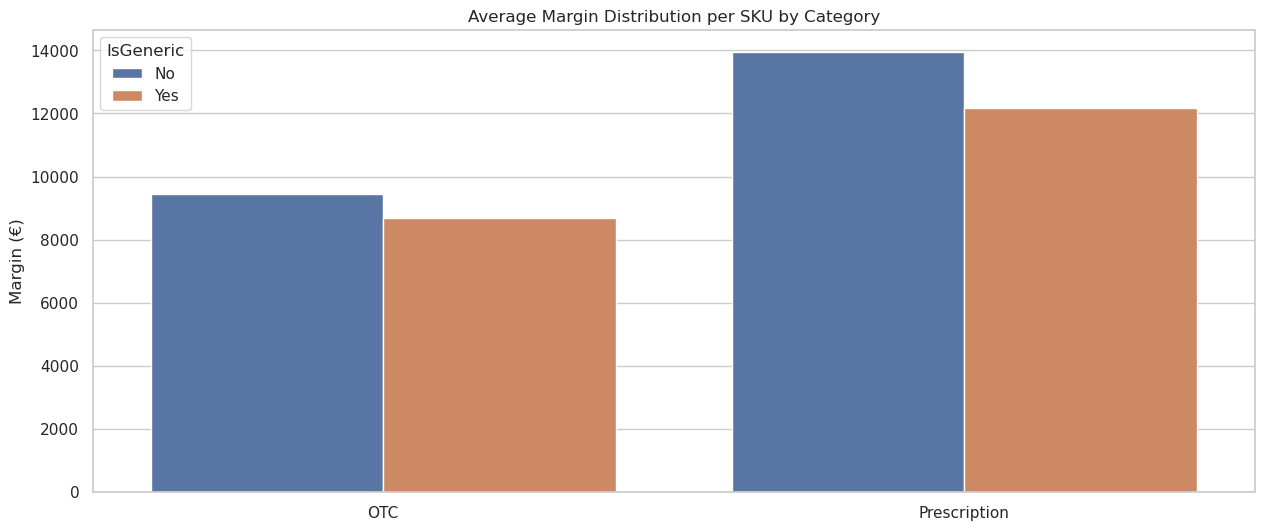

In [102]:
plt.figure(figsize=(15,6))
sns.barplot(data=sku_performance,x="Category",y="avg_margin",hue="IsGeneric")
plt.title('Average Margin Distribution per SKU by Category')
plt.xlabel('')
plt.ylabel('Margin (€)')
plt.show()

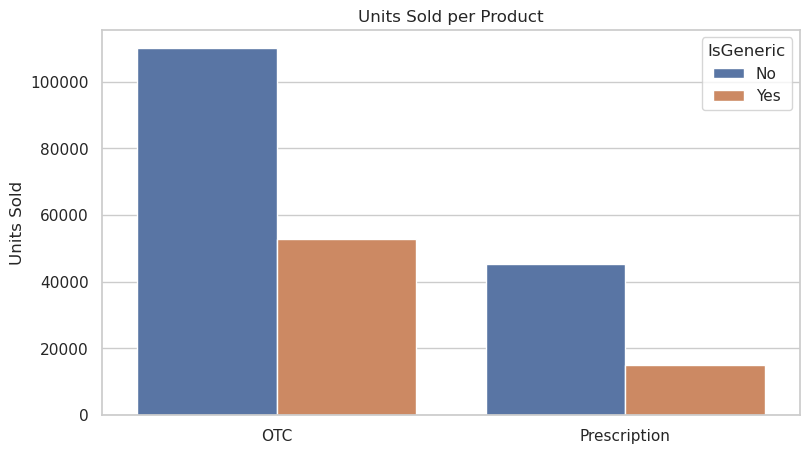

In [103]:
plt.figure(figsize=(9,5))

sns.barplot(data=sku_performance, x='Category',y='total_units',hue='IsGeneric')

plt.title('Units Sold per Product')
plt.xlabel('')
plt.ylabel('Units Sold')

plt.show()

In [104]:
margin_pct = second_merge.groupby('IsGeneric').agg(Revenue=('RevenueEUR','sum'), Margin=('MarginEUR','sum')).reset_index()

margin_pct['MarginPct'] = margin_pct['Margin'] /margin_pct['Revenue'] * 100


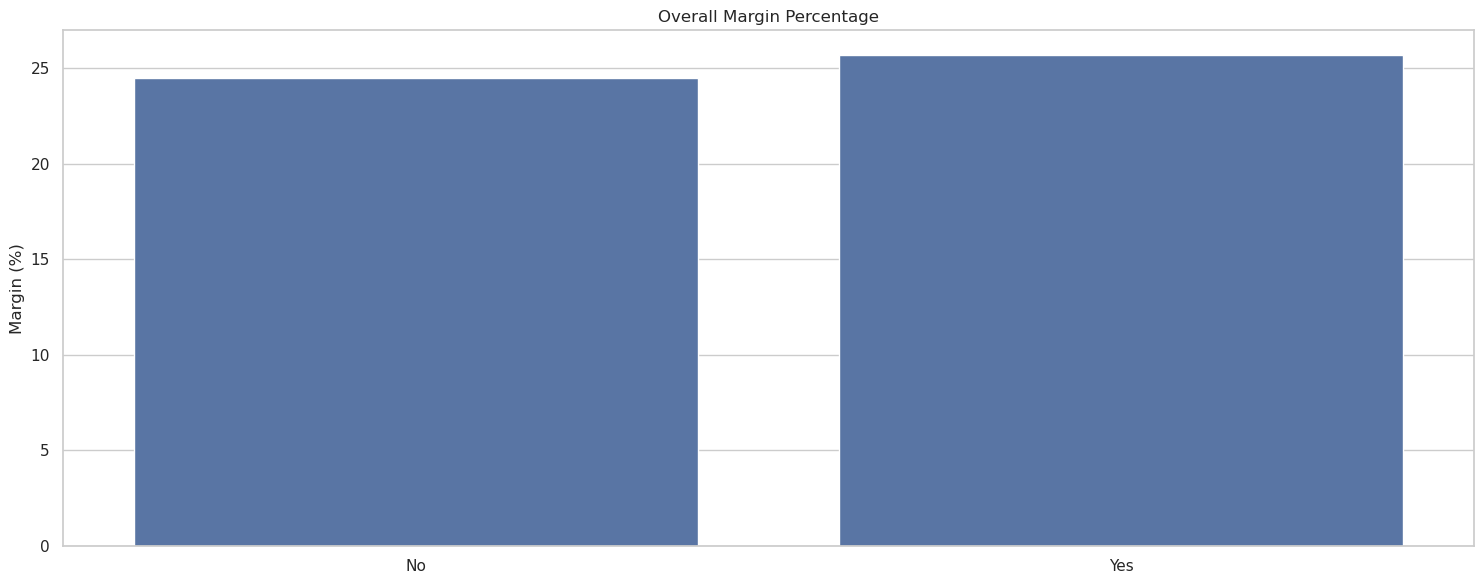

In [105]:
plt.figure(figsize=(15,6))

sns.barplot(data=margin_pct,x='IsGeneric',y='MarginPct')

plt.title('Overall Margin Percentage')
plt.xlabel('')
plt.ylabel('Margin (%)')

plt.tight_layout()
plt.show()